# Scalar, Vector, and Matrix Products: The Building Blocks

Before diving into sophisticated linear algebra patterns, we need to understand the **basic shapes** of multiplication:

| Operation | Inputs | Output | Example |
|-----------|--------|--------|---------|
| Scalar × Scalar | number, number | number | $3 \times 4 = 12$ |
| Scalar × Vector | number, vector | vector | $2 \times [1, 2, 3] = [2, 4, 6]$ |
| Scalar × Matrix | number, matrix | matrix | scales all entries |
| Vector × Vector | depends on orientation! | scalar or matrix | **This is key** |

The last row is where the magic happens. The **shape** of the result depends on how we orient the vectors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

---
## 1. Scalar Products: Scaling Everything

When you multiply by a scalar, you **scale** every element:

$$c \cdot \mathbf{v} = c \cdot \begin{pmatrix} v_1 \\ v_2 \\ v_3 \end{pmatrix} = \begin{pmatrix} c \cdot v_1 \\ c \cdot v_2 \\ c \cdot v_3 \end{pmatrix}$$

In [2]:
# Scalar × Vector
v = np.array([1, 2, 3])
c = 2.5

print(f"Vector v = {v}")
print(f"Scalar c = {c}")
print(f"c × v = {c * v}")
print(f"\nEach element is scaled by {c}")

Vector v = [1 2 3]
Scalar c = 2.5
c × v = [2.5 5.  7.5]

Each element is scaled by 2.5


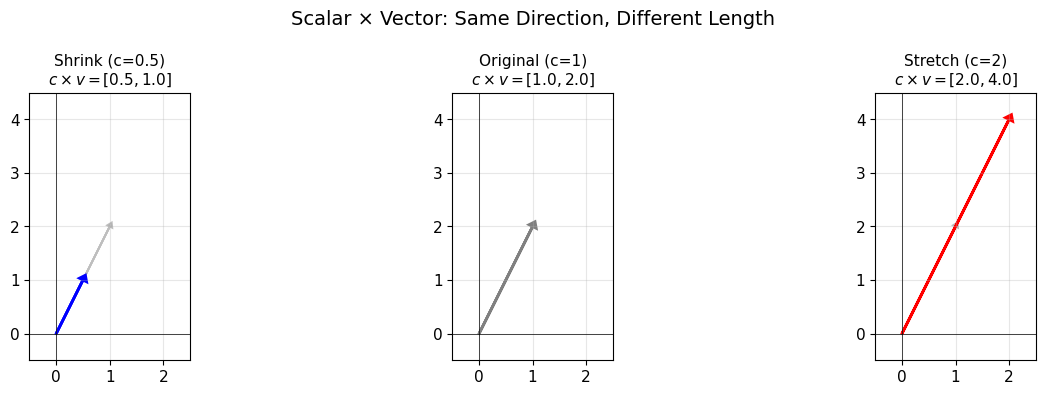

In [3]:
# Visualize scalar multiplication as stretching/shrinking
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

v = np.array([1, 2])
scalars = [0.5, 1.0, 2.0]
colors = ['blue', 'gray', 'red']
labels = ['Shrink (c=0.5)', 'Original (c=1)', 'Stretch (c=2)']

for ax, c, color, label in zip(axes, scalars, colors, labels):
    scaled = c * v
    ax.arrow(0, 0, v[0], v[1], head_width=0.1, head_length=0.08, 
             fc='lightgray', ec='gray', linewidth=1.5, alpha=0.5)
    ax.arrow(0, 0, scaled[0], scaled[1], head_width=0.15, head_length=0.1, 
             fc=color, ec=color, linewidth=2)
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 4.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{label}\n$c \\times v = [{scaled[0]:.1f}, {scaled[1]:.1f}]$', fontsize=11)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('Scalar × Vector: Same Direction, Different Length', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Scalar × Matrix
M = np.array([[1, 2], [3, 4]])
c = 3

print("Matrix M:")
print(M)
print(f"\nScalar c = {c}")
print(f"\nc × M:")
print(c * M)
print("\nEvery entry is multiplied by c")

Matrix M:
[[1 2]
 [3 4]]

Scalar c = 3

c × M:
[[ 3  6]
 [ 9 12]]

Every entry is multiplied by c


---
## 2. Vector × Vector: Shape Matters!

This is where things get interesting. Two vectors can multiply to give:
- A **scalar** (inner product / dot product)
- A **matrix** (outer product)

The difference? **Orientation**.

### The Shape Rule

Matrix multiplication follows: $(m \times n) \cdot (n \times p) = (m \times p)$

- **Row × Column** = scalar: $(1 \times n) \cdot (n \times 1) = (1 \times 1)$ → **Inner product**
- **Column × Row** = matrix: $(m \times 1) \cdot (1 \times n) = (m \times n)$ → **Outer product**

In [5]:
# Same vectors, different results based on orientation
x = np.array([1, 2, 3])  # In NumPy, 1D arrays are flexible
y = np.array([4, 5, 6])

# Inner product: x.T @ y (row times column)
inner = x @ y  # or np.dot(x, y) or np.inner(x, y)
print("INNER PRODUCT (x.T @ y): row × column → scalar")
print(f"x = {x}")
print(f"y = {y}")
print(f"x · y = {x[0]}×{y[0]} + {x[1]}×{y[1]} + {x[2]}×{y[2]} = {inner}")
print(f"Shape: scalar\n")

# Outer product: x @ y.T (column times row)
outer = np.outer(x, y)  # or x.reshape(-1,1) @ y.reshape(1,-1)
print("OUTER PRODUCT (x @ y.T): column × row → matrix")
print(f"Result:")
print(outer)
print(f"Shape: {outer.shape}")

INNER PRODUCT (x.T @ y): row × column → scalar
x = [1 2 3]
y = [4 5 6]
x · y = 1×4 + 2×5 + 3×6 = 32
Shape: scalar

OUTER PRODUCT (x @ y.T): column × row → matrix
Result:
[[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]
Shape: (3, 3)


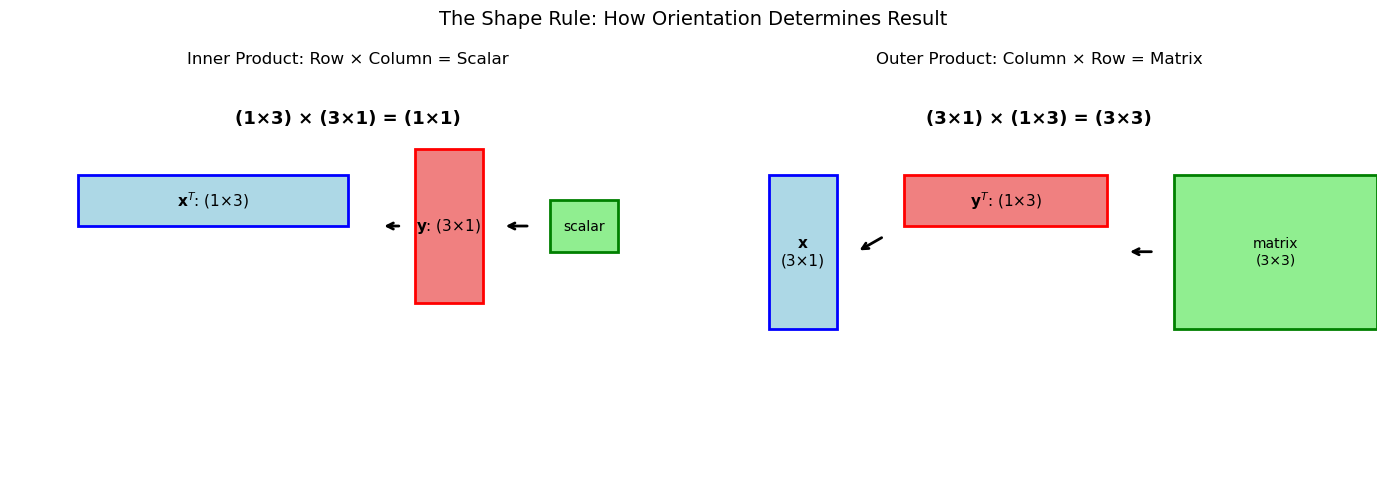

In [6]:
# Visualize the shape rule
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inner product visualization
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 8)

# Draw row vector (1×3)
row = Rectangle((1, 5), 4, 1, fill=True, facecolor='lightblue', edgecolor='blue', linewidth=2)
ax1.add_patch(row)
ax1.text(3, 5.5, '$\mathbf{x}^T$: (1×3)', ha='center', va='center', fontsize=11)

# Draw column vector (3×1)
col = Rectangle((6, 3.5), 1, 3, fill=True, facecolor='lightcoral', edgecolor='red', linewidth=2)
ax1.add_patch(col)
ax1.text(6.5, 5, '$\mathbf{y}$: (3×1)', ha='center', va='center', fontsize=11)

# Draw result (1×1 = scalar)
result = Rectangle((8, 4.5), 1, 1, fill=True, facecolor='lightgreen', edgecolor='green', linewidth=2)
ax1.add_patch(result)
ax1.text(8.5, 5, 'scalar', ha='center', va='center', fontsize=10)

ax1.annotate('', xy=(5.5, 5), xytext=(5.8, 5), 
             arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax1.annotate('', xy=(7.3, 5), xytext=(7.7, 5), 
             arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax1.text(5, 7, '(1×3) × (3×1) = (1×1)', ha='center', fontsize=13, fontweight='bold')
ax1.set_title('Inner Product: Row × Column = Scalar', fontsize=12)
ax1.axis('off')

# Outer product visualization
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 8)

# Draw column vector (3×1)
col2 = Rectangle((1, 3), 1, 3, fill=True, facecolor='lightblue', edgecolor='blue', linewidth=2)
ax2.add_patch(col2)
ax2.text(1.5, 4.5, '$\mathbf{x}$\n(3×1)', ha='center', va='center', fontsize=11)

# Draw row vector (1×3)
row2 = Rectangle((3, 5), 3, 1, fill=True, facecolor='lightcoral', edgecolor='red', linewidth=2)
ax2.add_patch(row2)
ax2.text(4.5, 5.5, '$\mathbf{y}^T$: (1×3)', ha='center', va='center', fontsize=11)

# Draw result (3×3 matrix)
result2 = Rectangle((7, 3), 3, 3, fill=True, facecolor='lightgreen', edgecolor='green', linewidth=2)
ax2.add_patch(result2)
ax2.text(8.5, 4.5, 'matrix\n(3×3)', ha='center', va='center', fontsize=10)

ax2.annotate('', xy=(2.3, 4.5), xytext=(2.7, 4.8), 
             arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax2.annotate('', xy=(6.3, 4.5), xytext=(6.7, 4.5), 
             arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax2.text(5, 7, '(3×1) × (1×3) = (3×3)', ha='center', fontsize=13, fontweight='bold')
ax2.set_title('Outer Product: Column × Row = Matrix', fontsize=12)
ax2.axis('off')

plt.suptitle('The Shape Rule: How Orientation Determines Result', fontsize=14)
plt.tight_layout()
plt.show()

---
## Real-World Scenario: Grocery Shopping

Let's see how these operations appear in everyday life.

**Scenario**: You're shopping for groceries. You have:
- **Quantities**: a vector of how many of each item you want
- **Prices**: a vector of price per item

Different multiplications answer different questions.

In [7]:
# Grocery shopping example
items = ['Apples', 'Bread', 'Milk', 'Eggs']
quantities = np.array([6, 2, 1, 12])     # How many of each
prices = np.array([0.50, 3.00, 4.00, 0.25])  # Price per unit ($)

print("Shopping List")
print("=" * 40)
for item, qty, price in zip(items, quantities, prices):
    print(f"{item:12} qty: {qty:3}  @ ${price:.2f} each")
print("=" * 40)

Shopping List
Apples       qty:   6  @ $0.50 each
Bread        qty:   2  @ $3.00 each
Milk         qty:   1  @ $4.00 each
Eggs         qty:  12  @ $0.25 each


In [8]:
# SCALAR × VECTOR: "What if everything costs 10% more?"
inflation = 1.10
new_prices = inflation * prices

print("Scalar × Vector: Price increase")
print("-" * 40)
print(f"Original prices: {prices}")
print(f"After 10% increase: {new_prices}")
print(f"\nEvery price scaled by {inflation}")

Scalar × Vector: Price increase
----------------------------------------
Original prices: [0.5  3.   4.   0.25]
After 10% increase: [0.55  3.3   4.4   0.275]

Every price scaled by 1.1


In [9]:
# INNER PRODUCT: "What's my total bill?"
total_bill = quantities @ prices  # or np.dot(quantities, prices)

print("Inner Product: Total cost")
print("-" * 40)
print(f"Quantities: {quantities}")
print(f"Prices:     {prices}")
print(f"\nTotal = 6×$0.50 + 2×$3.00 + 1×$4.00 + 12×$0.25")
print(f"      = ${6*0.50:.2f} + ${2*3:.2f} + ${1*4:.2f} + ${12*0.25:.2f}")
print(f"      = ${total_bill:.2f}")
print(f"\nInner product → single number (total)")

Inner Product: Total cost
----------------------------------------
Quantities: [ 6  2  1 12]
Prices:     [0.5  3.   4.   0.25]

Total = 6×$0.50 + 2×$3.00 + 1×$4.00 + 12×$0.25
      = $3.00 + $6.00 + $4.00 + $3.00
      = $16.00

Inner product → single number (total)


In [10]:
# OUTER PRODUCT: "Cost matrix for different shopping scenarios"
# What if we want to see cost per item for different quantity scenarios?
scenarios = np.array([1, 2, 5])  # Buy 1, 2, or 5 of everything

# Outer product creates a table: rows = items, columns = scenarios
cost_matrix = np.outer(prices, scenarios)

print("Outer Product: Cost matrix")
print("-" * 40)
print(f"Prices per item: {prices}")
print(f"Quantity scenarios: {scenarios}")
print(f"\nCost matrix (price × quantity for each combination):")
print(f"{'':12} Buy 1   Buy 2   Buy 5")
for i, item in enumerate(items):
    print(f"{item:12} ${cost_matrix[i,0]:5.2f}  ${cost_matrix[i,1]:5.2f}  ${cost_matrix[i,2]:5.2f}")
print(f"\nOuter product → matrix (all combinations)")

Outer Product: Cost matrix
----------------------------------------
Prices per item: [0.5  3.   4.   0.25]
Quantity scenarios: [1 2 5]

Cost matrix (price × quantity for each combination):
             Buy 1   Buy 2   Buy 5
Apples       $ 0.50  $ 1.00  $ 2.50
Bread        $ 3.00  $ 6.00  $15.00
Milk         $ 4.00  $ 8.00  $20.00
Eggs         $ 0.25  $ 0.50  $ 1.25

Outer product → matrix (all combinations)


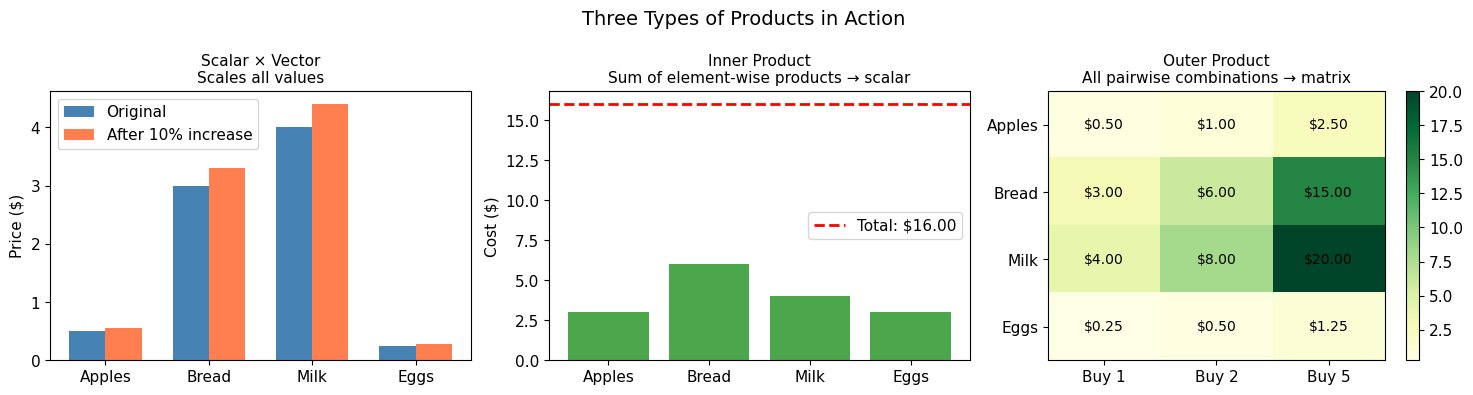

In [11]:
# Visualize all three operations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Scalar × Vector
ax1 = axes[0]
x = np.arange(len(items))
width = 0.35
ax1.bar(x - width/2, prices, width, label='Original', color='steelblue')
ax1.bar(x + width/2, new_prices, width, label='After 10% increase', color='coral')
ax1.set_xticks(x)
ax1.set_xticklabels(items)
ax1.set_ylabel('Price ($)')
ax1.set_title('Scalar × Vector\nScales all values', fontsize=11)
ax1.legend()

# Inner Product
ax2 = axes[1]
item_costs = quantities * prices
ax2.bar(items, item_costs, color='green', alpha=0.7)
ax2.axhline(y=total_bill, color='red', linestyle='--', linewidth=2, label=f'Total: ${total_bill:.2f}')
ax2.set_ylabel('Cost ($)')
ax2.set_title('Inner Product\nSum of element-wise products → scalar', fontsize=11)
ax2.legend()

# Outer Product
ax3 = axes[2]
im = ax3.imshow(cost_matrix, cmap='YlGn', aspect='auto')
ax3.set_xticks([0, 1, 2])
ax3.set_xticklabels(['Buy 1', 'Buy 2', 'Buy 5'])
ax3.set_yticks(range(len(items)))
ax3.set_yticklabels(items)
for i in range(len(items)):
    for j in range(3):
        ax3.text(j, i, f'${cost_matrix[i,j]:.2f}', ha='center', va='center', fontsize=10)
ax3.set_title('Outer Product\nAll pairwise combinations → matrix', fontsize=11)
plt.colorbar(im, ax=ax3)

plt.suptitle('Three Types of Products in Action', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. The Shape Rule: Why It Works

Matrix multiplication has a **compatibility rule**:

$$\underbrace{(m \times n)}_{\text{left matrix}} \times \underbrace{(n \times p)}_{\text{right matrix}} = \underbrace{(m \times p)}_{\text{result}}$$

**The inner dimensions must match!** (The $n$ cancels out)

This is why:
- $(1 \times 3) \times (3 \times 1) = (1 \times 1)$ ✓ Inner product works
- $(3 \times 1) \times (1 \times 3) = (3 \times 3)$ ✓ Outer product works
- $(3 \times 1) \times (3 \times 1) = ???$ ✗ Dimensions don't match!

In [12]:
# Demonstrate the shape rule
A = np.random.randn(2, 3)  # 2×3
B = np.random.randn(3, 4)  # 3×4

print("Shape Compatibility Demo")
print("=" * 40)
print(f"A shape: {A.shape}")
print(f"B shape: {B.shape}")
print(f"\n(2×3) × (3×4) = (2×4)")
print(f"      ↑   ↑")
print(f"      └───┘ These must match!")
print(f"\nResult shape: {(A @ B).shape}")

Shape Compatibility Demo
A shape: (2, 3)
B shape: (3, 4)

(2×3) × (3×4) = (2×4)
      ↑   ↑
      └───┘ These must match!

Result shape: (2, 4)


In [13]:
# What happens when dimensions don't match?
x = np.array([[1], [2], [3]])  # 3×1 column vector
y = np.array([[4], [5], [6]])  # 3×1 column vector

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")
print("\n(3×1) × (3×1) → inner dims: 1 ≠ 3")
print("Cannot multiply directly!")

try:
    result = x @ y
except ValueError as e:
    print(f"\nError: {e}")

print("\nSolution: Transpose one of them!")
print(f"x.T @ y = (1×3) × (3×1) = (1×1) → {(x.T @ y)[0,0]} (inner product)")
print(f"x @ y.T = (3×1) × (1×3) = (3×3) → matrix (outer product)")

x shape: (3, 1)
y shape: (3, 1)

(3×1) × (3×1) → inner dims: 1 ≠ 3
Cannot multiply directly!

Error: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 1)

Solution: Transpose one of them!
x.T @ y = (1×3) × (3×1) = (1×1) → 32 (inner product)
x @ y.T = (3×1) × (1×3) = (3×3) → matrix (outer product)


---
## 4. Quick Reference: Product Types

| Product Type | Formula | Shapes | Result | Use Case |
|-------------|---------|--------|--------|----------|
| Scalar × Vector | $c \mathbf{v}$ | number × $(n,)$ | $(n,)$ | Scaling |
| Scalar × Matrix | $c \mathbf{M}$ | number × $(m,n)$ | $(m,n)$ | Scaling |
| Inner Product | $\mathbf{x}^T \mathbf{y}$ | $(1,n) \times (n,1)$ | scalar | Similarity, totals |
| Outer Product | $\mathbf{x} \mathbf{y}^T$ | $(m,1) \times (1,n)$ | $(m,n)$ | All combinations |
| Matrix-Vector | $\mathbf{A} \mathbf{x}$ | $(m,n) \times (n,1)$ | $(m,1)$ | Transformation |
| Matrix-Matrix | $\mathbf{A} \mathbf{B}$ | $(m,n) \times (n,p)$ | $(m,p)$ | Composition |

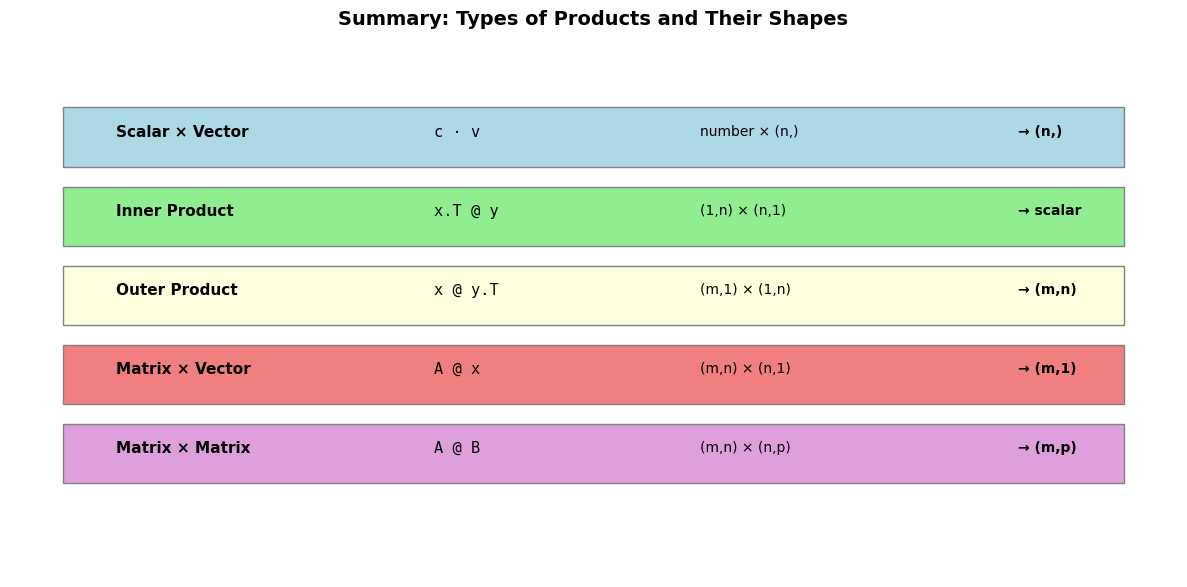

In [14]:
# Summary visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Create a visual summary
products = [
    ('Scalar × Vector', 'c · v', 'number × (n,)', '(n,)', 'lightblue'),
    ('Inner Product', 'x.T @ y', '(1,n) × (n,1)', 'scalar', 'lightgreen'),
    ('Outer Product', 'x @ y.T', '(m,1) × (1,n)', '(m,n)', 'lightyellow'),
    ('Matrix × Vector', 'A @ x', '(m,n) × (n,1)', '(m,1)', 'lightcoral'),
    ('Matrix × Matrix', 'A @ B', '(m,n) × (n,p)', '(m,p)', 'plum'),
]

for i, (name, formula, shapes, result, color) in enumerate(products):
    y = 4 - i * 0.8
    rect = Rectangle((0.5, y-0.35), 10, 0.6, facecolor=color, edgecolor='gray', linewidth=1)
    ax.add_patch(rect)
    ax.text(1, y, name, fontsize=11, fontweight='bold', va='center')
    ax.text(4, y, formula, fontsize=11, va='center', family='monospace')
    ax.text(6.5, y, shapes, fontsize=10, va='center')
    ax.text(9.5, y, f'→ {result}', fontsize=10, va='center', fontweight='bold')

ax.set_xlim(0, 11)
ax.set_ylim(-0.5, 5)
ax.axis('off')
ax.set_title('Summary: Types of Products and Their Shapes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Key Takeaways

1. **Scalar multiplication** scales every element — simple and intuitive

2. **Vector × Vector depends on orientation**:
   - Row × Column → scalar (inner product)
   - Column × Row → matrix (outer product)

3. **The shape rule**: $(m \times n) \cdot (n \times p) = (m \times p)$
   - Inner dimensions must match
   - Result takes outer dimensions

4. **In NumPy**:
   - `@` or `np.dot()` for matrix/vector multiplication
   - `np.outer()` for outer products
   - `*` for element-wise (Hadamard) product

**Next**: We'll explore the **inner product** in depth — measuring alignment and similarity between vectors.